# karto4ki — анализ статистики карточек

Источник данных: Settings → «Экспортировать в CSV». Формат — см. [.claude/STATS-ANALYSIS-SKILL.md](../.claude/STATS-ANALYSIS-SKILL.md).

In [1]:
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Шрифт с поддержкой CJK + кириллицы (macOS).
plt.rcParams['font.family'] = ['Hiragino Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font='Hiragino Sans')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## Загрузка данных

CSV лежат рядом с notebook (`analysis/*.csv`). Подхватываю самые свежие по timestamp.

In [2]:
DATA_DIR = Path('.')

def latest(pattern: str) -> Path | None:
    matches = sorted(DATA_DIR.glob(pattern))
    return matches[-1] if matches else None

stats_path = latest('question_stats_*.csv')
cards_path = latest('cards_*.csv')
print('stats:', stats_path)
print('cards:', cards_path)

stats: question_stats_20260515_182108.csv
cards: cards_20260515_182108.csv


In [3]:
stats = pd.read_csv(stats_path)
cards = pd.read_csv(cards_path)
print('stats:', stats.shape)
print('cards:', cards.shape)
stats.head()

stats: (624, 29)
cards: (299, 7)


,question_key,front_text,back_text,total_shown,total_correct,total_incorrect,streak,accuracy,created_at,updated_at,last_shown_at,last_answered_at,days_since_last_shown,age_days,streak_contribution,decay_factor,new_factor,frequency_factor,score_no_noise,rank_global,in_mixup_pool,hosting_test_ids,hosting_group_ids,mixup_target_test_count,w_streak_negative,w_streak_positive,w_decay,w_new,w_freq
0,暇 ひま - свободен,暇,ひま - свободен,9,0,9,-9,0.000000,2026-03-20T16:29:40.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,49,56,0.5,1.0,0.0,1.000000,0.950000,1,0,NaN,NaN,0,0.5,0.35,0.3,0.2,0.15
1,文 ぶん - предложение,文,ぶん - предложение,9,0,9,-9,0.000000,2026-03-20T16:29:40.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,49,56,0.5,1.0,0.0,1.000000,0.950000,2,0,NaN,NaN,0,0.5,0.35,0.3,0.2,0.15
2,持 もつ - держать,持,もつ - держать,9,1,8,-7,0.111111,2026-03-20T16:29:40.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,49,56,0.5,1.0,0.0,0.888889,0.933333,3,0,NaN,NaN,0,0.5,0.35,0.3,0.2,0.15
3,道 みち (дорога),道,みち (дорога),19,6,13,-7,0.315789,2026-03-11T21:23:40.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,49,64,0.5,1.0,0.0,0.684211,0.902632,4,0,NaN,NaN,0,0.5,0.35,0.3,0.2,0.15
4,書 かく (писать),書,かく (писать),17,6,11,-5,0.352941,2026-03-11T21:23:40.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,2026-03-26T19:10:43.000,49,64,0.5,1.0,0.0,0.647059,0.897059,5,0,NaN,NaN,0,0.5,0.35,0.3,0.2,0.15


In [4]:
stats.describe()

,total_shown,total_correct,total_incorrect,streak,accuracy,days_since_last_shown,age_days,streak_contribution,decay_factor,new_factor,frequency_factor,score_no_noise,rank_global,in_mixup_pool,hosting_group_ids,mixup_target_test_count,w_streak_negative,w_streak_positive,w_decay,w_new,w_freq
count,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,181.0,624.000000,624.0,6.240000e+02,624.0,6.240000e+02,624.00
mean,5.564103,4.032051,1.532051,2.500000,0.703220,38.767628,53.991987,-0.121987,0.770726,0.344231,0.296780,0.222594,312.500000,0.290064,1.0,2.320513,0.5,3.500000e-01,0.3,2.000000e-01,0.15
std,5.295359,3.899491,2.367300,3.685031,0.346523,23.570914,21.719833,0.171253,0.307346,0.303588,0.346523,0.281157,180.277564,0.454156,0.0,3.633246,0.0,5.555568e-17,0.0,2.777784e-17,0.00
min,1.000000,0.000000,0.000000,-9.000000,0.000000,8.000000,8.000000,-0.350000,0.266667,0.000000,0.000000,-0.270000,1.000000,0.000000,1.0,0.000000,0.5,3.500000e-01,0.3,2.000000e-01,0.15
25%,2.000000,1.000000,0.000000,1.000000,0.528638,10.000000,41.000000,-0.280000,0.333333,0.000000,0.000000,0.048750,156.750000,0.000000,1.0,0.000000,0.5,3.500000e-01,0.3,2.000000e-01,0.15
50%,3.000000,3.000000,1.000000,2.000000,0.833333,48.000000,49.000000,-0.140000,1.000000,0.400000,0.166667,0.190000,312.500000,0.000000,1.0,0.000000,0.5,3.500000e-01,0.3,2.000000e-01,0.15
75%,9.000000,5.000000,2.000000,4.000000,1.000000,61.000000,73.000000,-0.070000,1.000000,0.600000,0.471362,0.390000,468.250000,1.000000,1.0,8.000000,0.5,3.500000e-01,0.3,2.000000e-01,0.15
max,30.000000,18.000000,14.000000,18.000000,1.000000,73.000000,89.000000,0.500000,1.000000,0.800000,1.000000,0.950000,624.000000,1.000000,1.0,8.000000,0.5,3.500000e-01,0.3,2.000000e-01,0.15


## Подготовка: пул + пересчёт score под другими весами

Анализируем только `in_mixup_pool == 1` — orphan-статы и вопросы вне пула не подмешиваются.
Функция `recompute_score` ниже **должна совпадать** с `ScoringCalculator.components` из Dart-кода.

In [5]:
pool = stats[stats['in_mixup_pool'] == 1].copy()
print(f'Пул: {len(pool)} вопросов из {len(stats)} ({len(pool)/len(stats):.0%})')

current_weights = stats[['w_streak_negative', 'w_streak_positive', 'w_decay', 'w_new', 'w_freq']].iloc[0].to_dict()
print('Текущие веса:', current_weights)

def recompute_score(df, w_neg=0.35, w_pos=0.35, w_decay=0.30, w_new=0.20, w_freq=0.15):
    streak = df['streak'].to_numpy()
    streak_contrib = np.where(
        streak < 0, w_neg * np.minimum(-streak / 5, 1.0),
        np.where(streak > 0, -w_pos * np.minimum(streak / 5, 1.0), 0.0)
    )
    days = df['days_since_last_shown']
    decay = (days.fillna(30) / 30).clip(0, 1).to_numpy()
    decay = np.where(days.isna(), 1.0, decay)
    new_f = (1 - (df['total_shown'] / 5).clip(0, 1)).to_numpy()
    freq = np.where(df['total_shown'] > 0,
                    df['total_incorrect'] / df['total_shown'].clip(lower=1),
                    0.5)
    return streak_contrib + w_decay * decay + w_new * new_f + w_freq * freq

Пул: 181 вопросов из 624 (29%)
Текущие веса: {'w_streak_negative': 0.5, 'w_streak_positive': 0.35, 'w_decay': 0.3, 'w_new': 0.2, 'w_freq': 0.15}


## 1. Распределения факторов

Если у фактора почти вся масса в одном бакете — вес ничего не решает. Если факторы сильно перекошены влево/вправо — это сигнал, что формула на этой популяции вырождена.

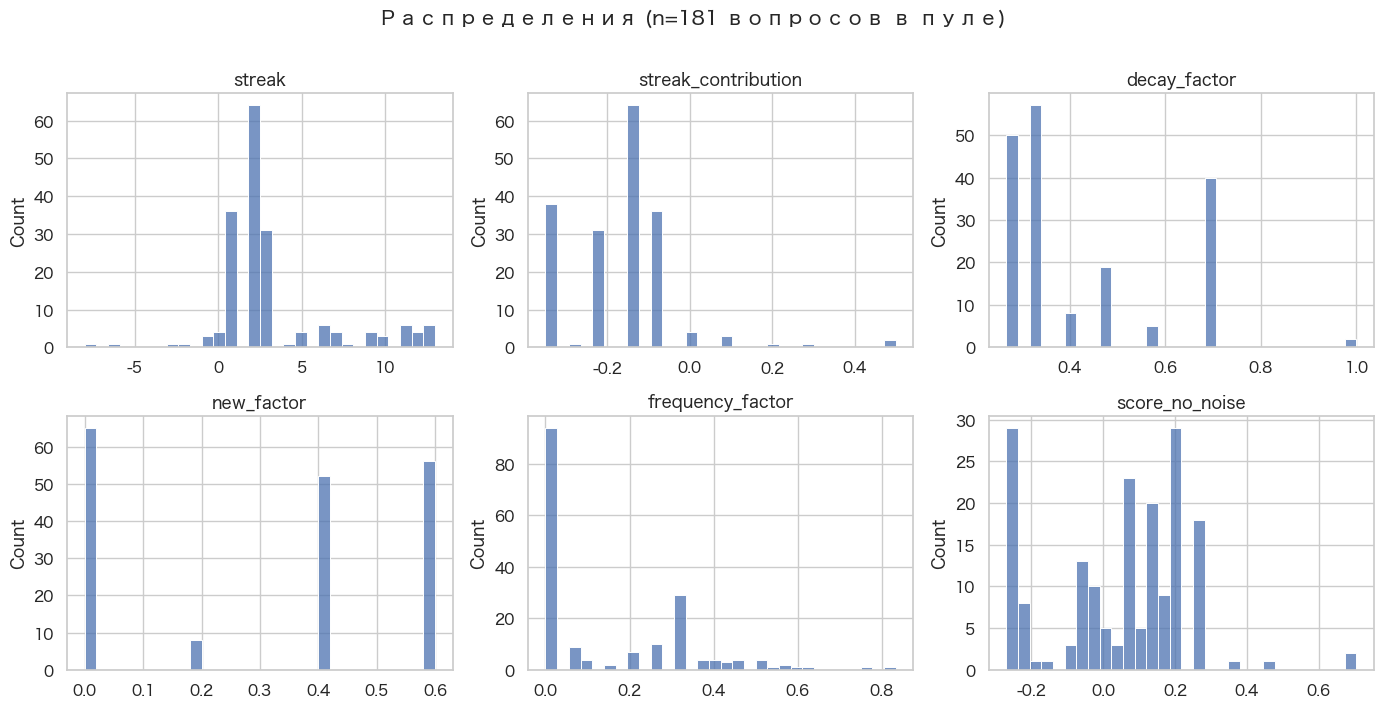

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()
cols = ['streak', 'streak_contribution', 'decay_factor', 'new_factor', 'frequency_factor', 'score_no_noise']
for ax, col in zip(axes, cols):
    sns.histplot(pool[col].dropna(), bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
fig.suptitle(f'Распределения (n={len(pool)} вопросов в пуле)', y=1.01)
plt.tight_layout()
plt.show()

## 2. Корреляции компонентов

Высокая корреляция = факторы дублируют друг друга, их совокупный вес фактически удваивается. Идеал — слабые корреляции (близко к нулю).

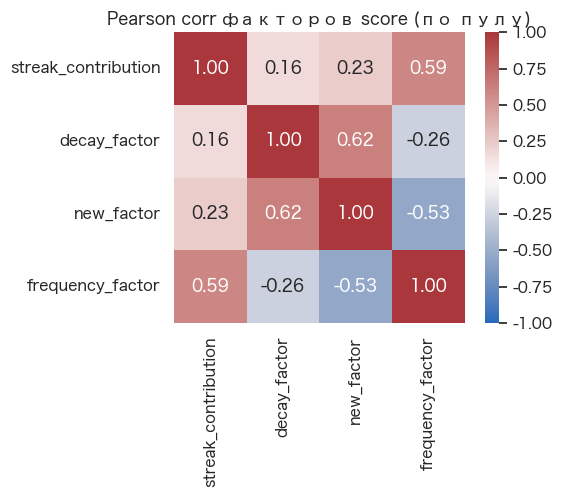

In [7]:
corr_cols = ['streak_contribution', 'decay_factor', 'new_factor', 'frequency_factor']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pool[corr_cols].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='vlag', ax=ax, square=True)
ax.set_title('Pearson corr факторов score (по пулу)')
plt.tight_layout()
plt.show()

## 3. Score vs Accuracy

Здоровое подмешивание выбирает вопросы с **низкой** accuracy. Если в правом верхнем углу много точек (высокая accuracy + высокий score) — что-то перекошено.

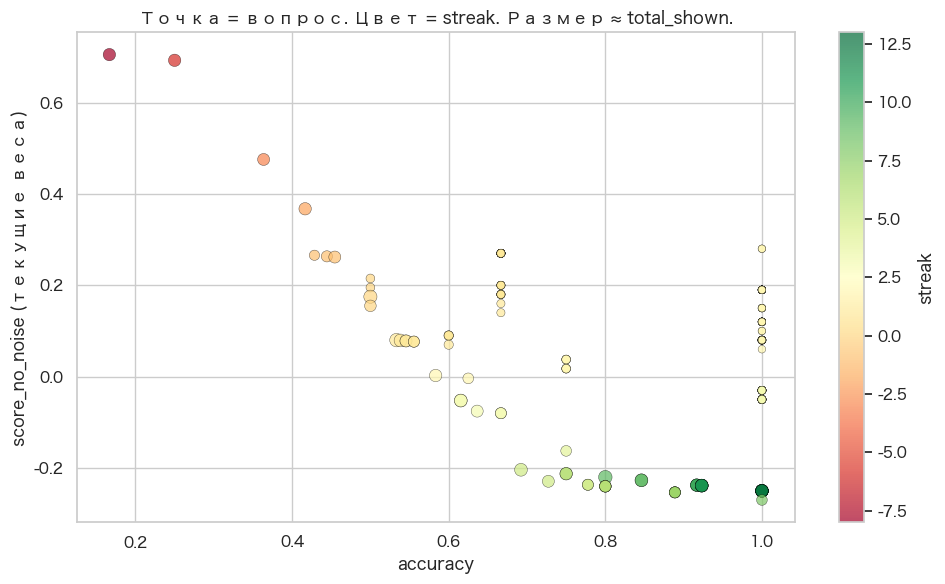

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = pool.dropna(subset=['accuracy']).copy()
sc = ax.scatter(
    plot_df['accuracy'], plot_df['score_no_noise'],
    c=plot_df['streak'], cmap='RdYlGn',
    s=20 + plot_df['total_shown'].clip(upper=20) * 5,
    alpha=0.7, edgecolor='black', linewidth=0.3,
)
ax.set_xlabel('accuracy')
ax.set_ylabel('score_no_noise (текущие веса)')
ax.set_title('Точка = вопрос. Цвет = streak. Размер ≈ total_shown.')
plt.colorbar(sc, label='streak')
plt.tight_layout()
plt.show()

## 4. Top-20 кандидатов — вклад факторов

Stacked bar: видно, какой фактор тянет вопрос вверх. Если top-20 у тебя весь зелёный (`new_factor`) или весь синий (`decay`) — этот фактор доминирует, и его вес стоит снизить.

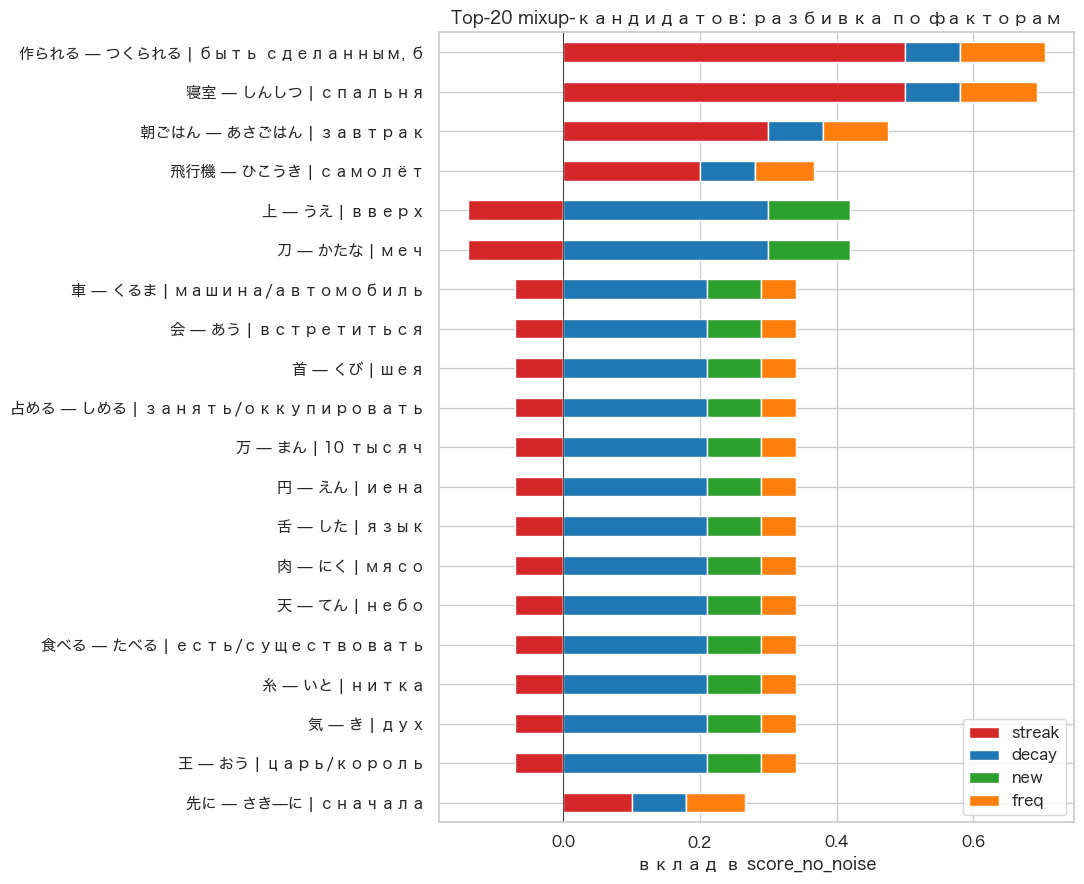

In [9]:
K = 20
top = pool.nlargest(K, 'score_no_noise').copy()
w = current_weights
top['c_streak'] = top['streak_contribution']
top['c_decay'] = w['w_decay'] * top['decay_factor']
top['c_new'] = w['w_new'] * top['new_factor']
top['c_freq'] = w['w_freq'] * top['frequency_factor']

labels = [f"{r.front_text} — {str(r.back_text)[:25]}" for _, r in top.iterrows()]
contribs = top[['c_streak', 'c_decay', 'c_new', 'c_freq']]
contribs.index = labels

fig, ax = plt.subplots(figsize=(11, 9))
contribs.plot(kind='barh', stacked=True, ax=ax,
              color=['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e'])
ax.invert_yaxis()
ax.set_xlabel('вклад в score_no_noise')
ax.set_title(f'Top-{K} mixup-кандидатов: разбивка по факторам')
ax.legend(['streak', 'decay', 'new', 'freq'], loc='lower right')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 5. Sensitivity: топ-K под сеткой весов

Меняем `w_decay × w_new`, остальные веса фиксируем текущими. Метрики top-K:
- **mean_accuracy** — средняя accuracy выбранных. **Чем ниже — тем лучше** (выбираем плохо известные).
- **pct_new** — доля «сырых» (total_shown < 3). Высокая = `w_new` доминирует, перебор.

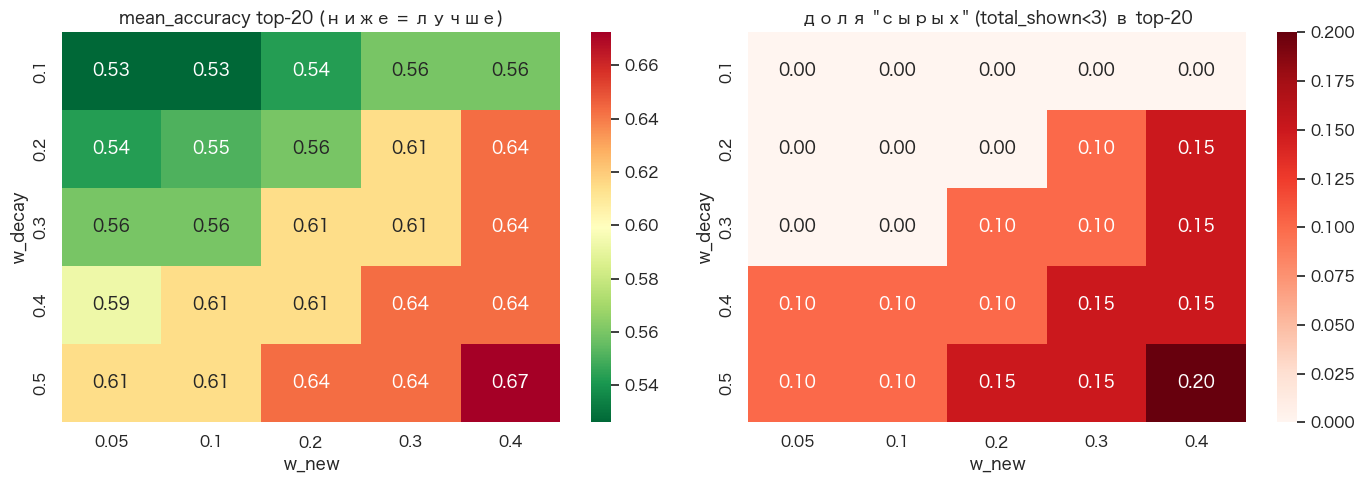


Текущие веса: {'w_streak_negative': 0.5, 'w_streak_positive': 0.35, 'w_decay': 0.3, 'w_new': 0.2, 'w_freq': 0.15}


In [10]:
K = 20
w_decays = [0.1, 0.2, 0.3, 0.4, 0.5]
w_news = [0.05, 0.1, 0.2, 0.3, 0.4]

rows = []
for w_d, w_n in product(w_decays, w_news):
    s = recompute_score(
        pool,
        w_neg=current_weights['w_streak_negative'],
        w_pos=current_weights['w_streak_positive'],
        w_decay=w_d, w_new=w_n,
        w_freq=current_weights['w_freq'],
    )
    top = pool.assign(s=s).nlargest(K, 's')
    rows.append({
        'w_decay': w_d,
        'w_new': w_n,
        'mean_accuracy': top['accuracy'].fillna(0).mean(),
        'pct_new': (top['total_shown'] < 3).mean(),
    })
grid = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pv_acc = grid.pivot(index='w_decay', columns='w_new', values='mean_accuracy')
sns.heatmap(pv_acc, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[0])
axes[0].set_title(f'mean_accuracy top-{K} (ниже = лучше)')
pv_new = grid.pivot(index='w_decay', columns='w_new', values='pct_new')
sns.heatmap(pv_new, annot=True, fmt='.2f', cmap='Reds', ax=axes[1])
axes[1].set_title(f'доля "сырых" (total_shown<3) в top-{K}')
plt.tight_layout()
plt.show()

print('\nТекущие веса:', {k: round(v, 2) for k, v in current_weights.items()})

## 6. Этап 1: active days + затухающий streak penalty

Две идеи:
- **active days** вместо календарных в decay (пользователь учится 2-3 раза в неделю, 30 календарных дней ≈ 8 активных)
- **penalty за положительный streak затухает** с давностью: `-w_pos × (streak/5) × (1 - decay)`. Старая отлично-знаемая карточка получает 0 штрафа, а свежевыученная — полный.

### 6.1 Подсчёт active days

«Активный день» = дата, в которую хоть одна карточка была отвечена. Берём union по `last_answered_at`.

⚠️ Долгосрочно это нужно считать в Dart из отдельной таблицы сессий — текущий метод недосчитает дни, когда пользователь зашёл, но не ответил ни на одну карточку (которые и так ни на что не повлияли в прошлом — но если ввести новый фактор, эту проблему придётся решать).

Активных дней: 23 (за 66 календарных)


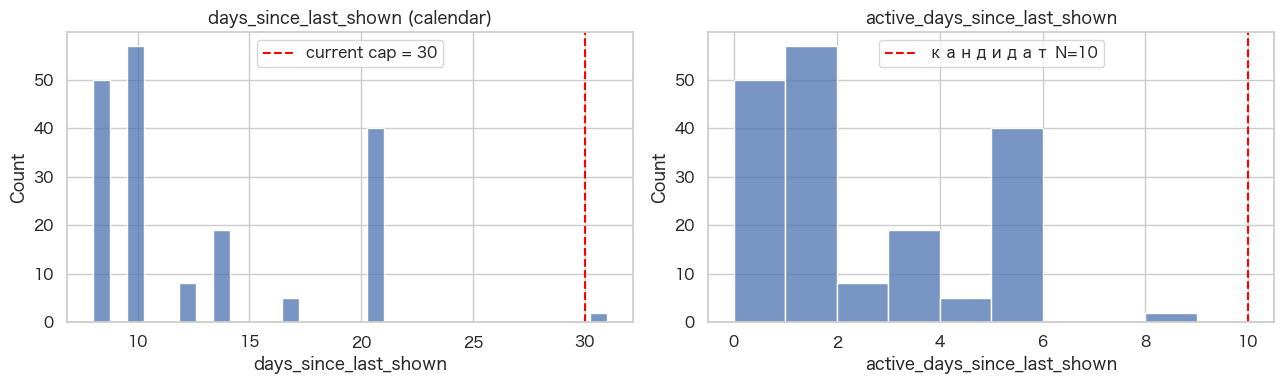


Для карточек со streak >= 3 (n=70):
 median calendar days_since: 10.0
 median active  days_since: 1.0


In [11]:
active_dates = pd.to_datetime(stats['last_answered_at']).dt.normalize().dropna()
active_sorted = np.sort(active_dates.unique())
days_span = pd.Timedelta(active_sorted[-1] - active_sorted[0]).days
print(f'Активных дней: {len(active_sorted)} (за {days_span} календарных)')

def active_days_since(ts):
    if pd.isna(ts):
        return np.nan
    return int((active_sorted > pd.to_datetime(ts).normalize()).sum())

stats['active_days_since_last_shown'] = pd.to_datetime(stats['last_shown_at']).apply(active_days_since)
pool['active_days_since_last_shown'] = stats.loc[pool.index, 'active_days_since_last_shown']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(pool['days_since_last_shown'].dropna(), bins=30, ax=axes[0])
axes[0].set_title('days_since_last_shown (calendar)')
axes[0].axvline(30, color='red', linestyle='--', label='current cap = 30')
axes[0].legend()

max_ads = int(pool['active_days_since_last_shown'].max())
sns.histplot(pool['active_days_since_last_shown'].dropna(), bins=range(0, max_ads + 2), ax=axes[1])
axes[1].set_title('active_days_since_last_shown')
axes[1].axvline(10, color='red', linestyle='--', label='кандидат N=10')
axes[1].legend()

plt.tight_layout()
plt.show()

hs = pool[pool['streak'] >= 3]
print(f'\nДля карточек со streak >= 3 (n={len(hs)}):')
print(f' median calendar days_since: {hs["days_since_last_shown"].median()}')
print(f' median active  days_since: {hs["active_days_since_last_shown"].median()}')

### 6.2 Новая формула score

Меняются две вещи:
- `decay_factor` считается от `active_days_since_last_shown / N` (вместо calendar days / 30)
- `streak_contribution` для **положительного** streak умножается на `(1 - active_decay)` — penalty затухает с давностью

Бонус за отрицательный streak не трогаем — «плохо знаю» актуально и сразу, и через месяц.

```
streak_contribution:
  если streak < 0:  +w_neg × min(-streak/5, 1)
  если streak > 0:  -w_pos × min(streak/5, 1) × (1 - active_decay)
  иначе: 0
score = streak_contrib + w_decay × active_decay + w_new × new + w_freq × freq
```

In [12]:
def recompute_score_v2(df, N=10, w_neg=0.5, w_pos=0.35, w_decay=0.30, w_new=0.20, w_freq=0.15):
    streak = df['streak'].to_numpy()
    ads = df['active_days_since_last_shown'].fillna(N).to_numpy()
    active_decay = np.clip(ads / N, 0, 1)

    streak_neg = np.minimum(np.maximum(-streak, 0) / 5, 1)
    streak_pos = np.minimum(np.maximum(streak, 0) / 5, 1)
    streak_contrib = w_neg * streak_neg - w_pos * streak_pos * (1 - active_decay)

    new_f = (1 - (df['total_shown'] / 5).clip(0, 1)).to_numpy()
    freq = np.where(df['total_shown'] > 0,
                    df['total_incorrect'] / df['total_shown'].clip(lower=1),
                    0.5)
    return streak_contrib + w_decay * active_decay + w_new * new_f + w_freq * freq

pool['score_new'] = recompute_score_v2(
    pool, N=10,
    w_neg=current_weights['w_streak_negative'],
    w_pos=current_weights['w_streak_positive'],
    w_decay=current_weights['w_decay'],
    w_new=current_weights['w_new'],
    w_freq=current_weights['w_freq'],
)
print(f'score_new: mean={pool["score_new"].mean():.3f}, std={pool["score_new"].std():.3f}')
print(f'score_no_noise (baseline): mean={pool["score_no_noise"].mean():.3f}, std={pool["score_no_noise"].std():.3f}')

score_new: mean=0.010, std=0.202
score_no_noise (baseline): mean=0.048, std=0.188


### 6.3 Diff: кто пришёл в top-20, кто ушёл

Сравниваем `score_no_noise` (текущая прод-формула) и `score_new` (новая). Хотим увидеть, что **«старые с высоким streak»** полезут наверх, а не уйдут совсем плохо-знаемые.

In [13]:
K = 20
top_old = pool.nlargest(K, 'score_no_noise')[
    ['question_key','front_text','back_text','streak','total_shown','accuracy','active_days_since_last_shown','score_no_noise']
].assign(rank_old=range(1, K+1))
top_new = pool.nlargest(K, 'score_new')[
    ['question_key','front_text','back_text','streak','total_shown','accuracy','active_days_since_last_shown','score_no_noise','score_new']
].assign(rank_new=range(1, K+1))

old_keys = set(top_old['question_key'])
new_keys = set(top_new['question_key'])
stayed = old_keys & new_keys
came_in = new_keys - old_keys
left = old_keys - new_keys

print(f'Из старого top-{K}: осталось {len(stayed)}, ушло {len(left)}, пришло {len(came_in)}\n')

print('=== ПРИШЛИ в новый top-20 (то что хотели вернуть) ===')
came = top_new[top_new['question_key'].isin(came_in)].copy()
came['delta'] = came['score_new'] - came['score_no_noise']
view = came[['front_text','back_text','streak','total_shown','accuracy','active_days_since_last_shown','score_no_noise','score_new','delta','rank_new']]
view.columns = ['front','back','streak','n_shown','acc','active_days','score_old','score_new','delta','rank_new']
print(view.round(2).to_string(index=False))

print('\n=== УШЛИ из top-20 ===')
gone = pool[pool['question_key'].isin(left)].copy()
gone['score_new_val'] = recompute_score_v2(
    gone, N=10,
    w_neg=current_weights['w_streak_negative'],
    w_pos=current_weights['w_streak_positive'],
    w_decay=current_weights['w_decay'],
    w_new=current_weights['w_new'],
    w_freq=current_weights['w_freq'],
)
view = gone[['front_text','back_text','streak','total_shown','accuracy','active_days_since_last_shown','score_no_noise','score_new_val']]
view.columns = ['front','back','streak','n_shown','acc','active_days','score_old','score_new']
print(view.sort_values('score_old', ascending=False).round(2).to_string(index=False))

Из старого top-20: осталось 19, ушло 1, пришло 1

=== ПРИШЛИ в новый top-20 (то что хотели вернуть) ===
front         back  streak  n_shown  acc  active_days  score_old  score_new  delta  rank_new
  少ない すくーない | мало       2        2  1.0            5       0.19        0.2   0.01        20

=== УШЛИ из top-20 ===
front           back  streak  n_shown  acc  active_days  score_old  score_new
   先に さき—に | сначала      -1        7 0.43            0       0.27       0.19


### 6.4 Sensitivity по `N`

Цель — найти `N`, при котором в top-20 попадают **старые с высоким streak** (то что мы хотим вернуть в подмешивание), но не ломается выбор плохо знаемых (`streak < 0`).

In [14]:
def metrics(top):
    return {
        'mean_acc': round(top['accuracy'].mean(), 3),
        'streak_neg_in_top': int((top['streak'] < 0).sum()),
        'long_streak_old_in_top': int(((top['streak'] >= 3) & (top['active_days_since_last_shown'] >= 5)).sum()),
        'new_raw_in_top': int((top['total_shown'] < 3).sum()),
    }

Ns = [3, 5, 7, 10, 14, 20]
rows = []
for N in Ns:
    s = recompute_score_v2(
        pool, N=N,
        w_neg=current_weights['w_streak_negative'],
        w_pos=current_weights['w_streak_positive'],
        w_decay=current_weights['w_decay'],
        w_new=current_weights['w_new'],
        w_freq=current_weights['w_freq'],
    )
    top = pool.assign(s=s).nlargest(20, 's')
    rows.append({'config': f'N={N}', **metrics(top)})

top_baseline = pool.nlargest(20, 'score_no_noise')
rows.append({'config': 'baseline (текущая формула)', **metrics(top_baseline)})

print('Метрики top-20 под разными N:')
print(pd.DataFrame(rows).to_string(index=False))
print('\nЛегенда:')
print(' streak_neg_in_top — карточек со streak<0 в топе (плохо знаемые)')
print(' long_streak_old_in_top — карточек со streak>=3 И active_days>=5 (то что мы хотим вернуть)')
print(' new_raw_in_top — сырых (total_shown<3)')

Метрики top-20 под разными N:
                    config  mean_acc  streak_neg_in_top  long_streak_old_in_top  new_raw_in_top
                       N=3     0.621                  2                       0               0
                       N=5     0.704                  2                       0               5
                       N=7     0.672                  3                       0               4
                      N=10     0.643                  4                       0               3
                      N=14     0.615                  5                       0               2
                      N=20     0.593                  7                       0               2
baseline (текущая формула)     0.615                  5                       0               2

Легенда:
 streak_neg_in_top — карточек со streak<0 в топе (плохо знаемые)
 long_streak_old_in_top — карточек со streak>=3 И active_days>=5 (то что мы хотим вернуть)
 new_raw_in_top — сырых (total_shown